# CMVAE hyperparameter grid search — Norman 2019 (100 % gamma 1.1)

Trains the discrepancy-VAE (CMVAE-full: `use_tf_only=False, use_GRN_priors=False, z_dim=None`)
under 10 hyperparameter configurations and compares prediction performance on the test set.

Original discrepancy-VAE defaults: `alpha_mmd=10, beta_kld=2, lambda_sparse=1e-3, lr=1e-3, batch_size=32, epochs=100`.

| # | Name | Change from original defaults | Rationale |
|---|---|---|---|
| 1 | `original` | — | Reference baseline |
| 2 | `batch64` | batch_size=64 | Better MMD gradient estimates |
| 3 | `mmd20` | alpha_mmd=20 | Stronger distributional matching |
| 4 | `mmd20_batch64` | alpha_mmd=20, batch_size=64 | Combines 2+3 |
| 5 | `boost_recon` | alpha_mmd=10, beta_kld=1, lambda_sparse=0.1 | Current best result |
| 6 | `sparse01` | lambda_sparse=0.1 | Tests if L1 increase drove boost_recon improvement |
| 7 | `kld05` | beta_kld=0.5 | Lower KLD pressure, keep everything else original |
| 8 | `mmd20_kld05` | alpha_mmd=20, beta_kld=0.5 | Maximally MMD-focused within safe regularisation |
| 9 | `lr1e4` | lr=1e-4 | Tests whether MSE spike is an optimisation instability |
| 10 | `slow_ramp` | epochs=200 | Doubles ramp window (epoch 5→100 instead of 5→50) |
| 11 | `lr1e4_b64` | lr=1e-4, batch_size=64 | Lower LR + better MMD estimates — both stabilise the MMD-MSE tension |

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "../../src")

import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from gcrl.grn.eigengenes import compute_eigengenes
from gcrl.training.train_gcrl_vae import VAEConfig, train_gcrl_vae
from gcrl.evaluation.prediction_eval import evaluate_predictions

In [3]:
# Control panel
_ctrl_labels = ["unperturbed", "control", "ctrl"]

DATA_PATH = "../../data/real/Norman2019/Norman2019_processed_100pct_gamma1p1.h5ad"
BASE_DIR  = "../../results/real/Norman2019/cmvae_grid_trial"

## 1. Load data and compute eigengenes

In [4]:
adata = ad.read_h5ad(DATA_PATH)
print(f"Loaded: {adata.shape[0]} cells × {adata.shape[1]} genes")

compute_eigengenes(
    adata,
    community_col="community",
    reference_query='intervention == "unperturbed"',
    mode="all_cells",
    method="PC",
    seed=42,
)
eig   = adata.obsm["X_comm_eig"]
n_eig = eig.shape[1]
print(f"Eigengene matrix: {eig.shape}  (n_cells × n_communities+1)")

Loaded: 35048 cells × 2703 genes


Eigengene matrix: (35048, 8)  (n_cells × n_communities+1)


## 2. Define configurations

All settings use `use_tf_only=False, use_GRN_priors=False, z_dim=None` (CMVAE-full).
Only the fields that differ from the original defaults are listed per setting.

In [5]:
# Original discrepancy-VAE defaults
_base = dict(
    use_tf_only    = False,
    use_GRN_priors = False,
    z_dim          = None,
    alpha_mmd_max  = 10.0,
    beta_kld_max   = 2.0,
    lambda_sparse  = 1e-3,
    lambda_mcc     = 1.0,   # irrelevant for CMVAE
    lr             = 1e-3,
    batch_size     = 32,
    epochs         = 3,   # TRIAL RUN
    seed           = 0,
)

SETTINGS = [
    # (name,            overrides)
    ("01_original",     {}),
    ("02_batch64",      dict(batch_size=64)),
    ("03_mmd20",        dict(alpha_mmd_max=20.0)),
    ("04_mmd20_b64",    dict(alpha_mmd_max=20.0, batch_size=64)),
    ("05_boost_recon",  dict(alpha_mmd_max=10.0, beta_kld_max=1.0, lambda_sparse=0.1)),
    ("06_sparse01",     dict(lambda_sparse=0.1)),
    ("07_kld05",        dict(beta_kld_max=0.5)),
    ("08_mmd20_kld05",  dict(alpha_mmd_max=20.0, beta_kld_max=0.5)),
    ("09_lr1e4",        dict(lr=1e-4)),
    ("10_slow_ramp",    dict(epochs=3)),  # TRIAL RUN: normally epochs=200
    ("11_lr1e4_b64",    dict(lr=1e-4, batch_size=64)),
]

print(f"{len(SETTINGS)} configurations defined")

11 configurations defined


## 3. Train all configurations

In [6]:
models    = {}
histories = {}

for name, overrides in SETTINGS:
    print(f"\n{'='*50}")
    print(f"Training: {name}  overrides={overrides}")
    print(f"{'='*50}")
    cfg = VAEConfig(outdir=f"{BASE_DIR}/{name}", **{**_base, **overrides})
    model, history = train_gcrl_vae(adata, cfg, eigengenes_key="X_comm_eig")
    models[name]    = model
    histories[name] = pd.DataFrame(history)

print("\nAll configurations trained.")


Training: 01_original  overrides={}
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_trial/01_original/

Training: 02_batch64  overrides={'batch_size': 64}
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_trial/02_batch64/

Training: 03_mmd20  overrides={'alpha_mmd_max': 20.0}
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


...

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_trial/09_lr1e4/

Training: 10_slow_ramp  overrides={'epochs': 3}
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_trial/10_slow_ramp/

Training: 11_lr1e4_b64  overrides={'lr': 0.0001, 'batch_size': 64}
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_trial/11_lr1e4_b64/

All configurations trained.


## 4. Predict and evaluate

In [7]:
_predict_kwargs = dict(
    set_key          = "set",
    intervention_key = "intervention",
    cell_type_key    = "cell_type",
    control_labels   = tuple(_ctrl_labels),
    seed             = 42,
)

metrics = {}

for name, _ in SETTINGS:
    preds = models[name].predict(adata, **_predict_kwargs)
    metrics[name] = evaluate_predictions(
        adata          = adata,
        preds          = preds,
        output_dir     = f"{BASE_DIR}/{name}",
        control_labels = tuple(_ctrl_labels),
    )
    cd_actual = metrics[name].query("metric_name == 'centroid_distance' and method == 'actual'")["metric_value"].median()
    cd_worst  = metrics[name].query("metric_name == 'centroid_distance' and method == 'worst_case'")["metric_value"].median()
    print(f"{name:<20}  actual={cd_actual:.4f}  worst_case={cd_worst:.4f}")

print("\nAll evaluations complete.")

01_original           actual=5.8915  worst_case=5.4667


02_batch64            actual=5.4765  worst_case=5.4667


03_mmd20              actual=5.8915  worst_case=5.4667


04_mmd20_b64          actual=5.4765  worst_case=5.4667


05_boost_recon        actual=5.7597  worst_case=5.4667


...

07_kld05              actual=5.8915  worst_case=5.4667


08_mmd20_kld05        actual=5.8915  worst_case=5.4667


09_lr1e4              actual=5.6673  worst_case=5.4667


10_slow_ramp          actual=5.8915  worst_case=5.4667


11_lr1e4_b64          actual=5.5296  worst_case=5.4667

All evaluations complete.


## 5. Training curves

One row per loss component, one line per configuration.

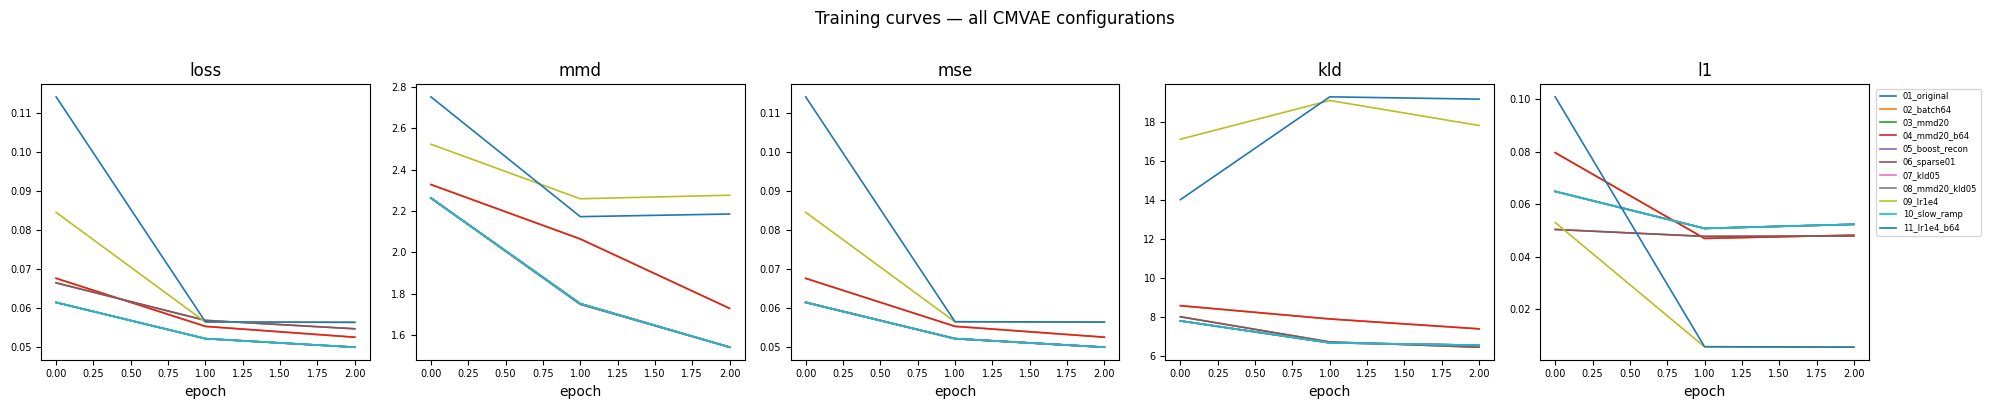

In [8]:
LOSS_COLS = ["loss", "mmd", "mse", "kld", "l1"]
cmap      = plt.get_cmap("tab10")
colors    = {name: cmap(i % 10) for i, (name, _) in enumerate(SETTINGS)}

fig, axes = plt.subplots(1, len(LOSS_COLS), figsize=(4 * len(LOSS_COLS), 4))

for ax, lc in zip(axes, LOSS_COLS):
    for name, _ in SETTINGS:
        df = histories[name]
        ax.plot(df["epoch"], df[lc], label=name, color=colors[name], linewidth=1.2)
    ax.set_title(lc)
    ax.set_xlabel("epoch")
    ax.tick_params(labelsize=7)

axes[-1].legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.suptitle("Training curves — all CMVAE configurations", y=1.01)
plt.tight_layout()
plt.show()

## 6. Performance summary table

In [9]:
rows = []
for name, _ in SETTINGS:
    df = metrics[name]
    for metric_name in ["centroid_distance", "rmse"]:
        for method in ["actual", "worst_case", "perfect_baseline"]:
            val = df.loc[
                (df["metric_name"] == metric_name) & (df["method"] == method),
                "metric_value"
            ].median()
            rows.append({"setting": name, "metric": metric_name, "method": method, "median": val})

summary = pd.DataFrame(rows)
pivot = summary.pivot_table(
    index="setting",
    columns=["metric", "method"],
    values="median",
).round(4)
# Sort by actual centroid distance (lower is better)
pivot = pivot.sort_values(("centroid_distance", "actual"))
print("Median metrics across all double-perturbation conditions (sorted by centroid_distance actual):")
pivot

Median metrics across all double-perturbation conditions (sorted by centroid_distance actual):


metric         centroid_distance                                rmse  \
method                    actual perfect_baseline worst_case  actual   
setting                                                                
02_batch64                5.4765           1.8756     5.4667  0.1053   
04_mmd20_b64              5.4765           1.8756     5.4667  0.1053   
11_lr1e4_b64              5.5296           1.8756     5.4667  0.1064   
09_lr1e4                  5.6673           1.8756     5.4667  0.1090   
06_sparse01               5.7597           1.8756     5.4667  0.1108   
05_boost_recon            5.7597           1.8756     5.4667  0.1108   
03_mmd20                  5.8915           1.8756     5.4667  0.1133   
01_original               5.8915           1.8756     5.4667  0.1133   
08_mmd20_kld05            5.8915           1.8756     5.4667  0.1133   
07_kld05                  5.8915           1.8756     5.4667  0.1133   
10_slow_ramp              5.8915           1.8756     5.4667  0.1133   

metric                                      
method         perfect_baseline worst_case  
setting                                     
02_batch64               0.0361     0.1051  
04_mmd20_b64             0.0361     0.1051  
11_lr1e4_b64             0.0361     0.1051  
09_lr1e4                 0.0361     0.1051  
06_sparse01              0.0361     0.1051  
05_boost_recon           0.0361     0.1051  
03_mmd20                 0.0361     0.1051  
01_original              0.0361     0.1051  
08_mmd20_kld05           0.0361     0.1051  
07_kld05                 0.0361     0.1051  
10_slow_ramp             0.0361     0.1051

## 7. Bar chart: median centroid distance

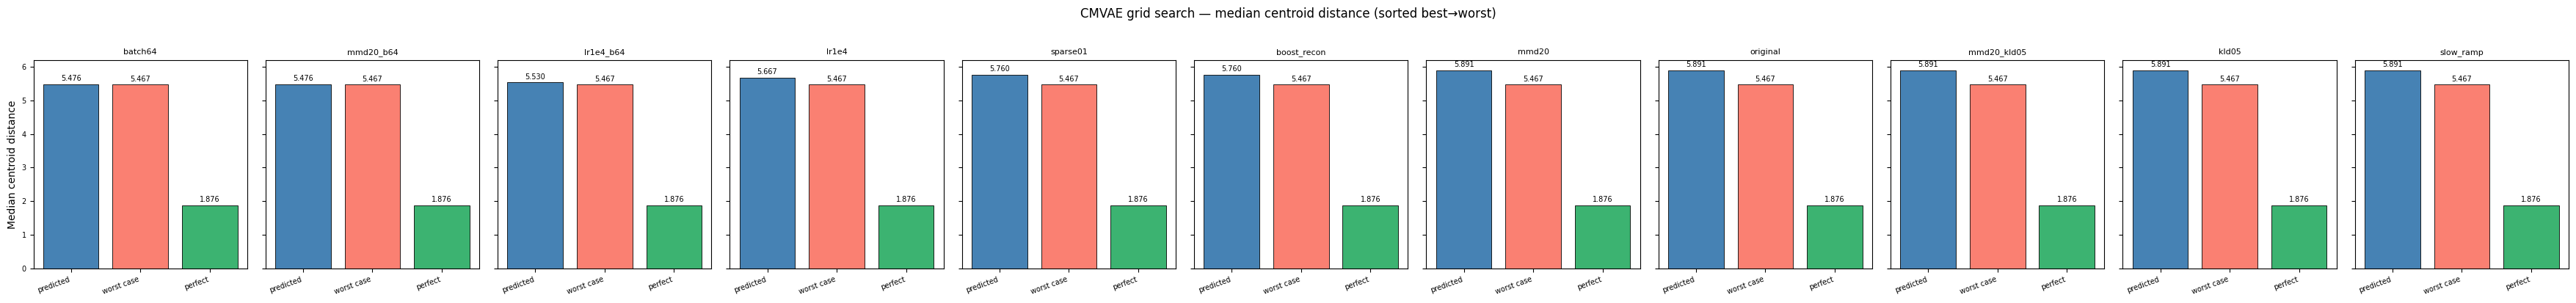

In [10]:
methods_order = ["actual", "worst_case", "perfect_baseline"]
method_colors = {"actual": "steelblue", "worst_case": "salmon", "perfect_baseline": "mediumseagreen"}

cd = summary[summary["metric"] == "centroid_distance"]
# Order settings by actual centroid distance
order = (
    cd[cd["method"] == "actual"]
    .sort_values("median")["setting"]
    .tolist()
)

n = len(order)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 4), sharey=True)

for ax, name in zip(axes, order):
    vals = cd[cd["setting"] == name].set_index("method")["median"].reindex(methods_order)
    bars = ax.bar(
        range(len(methods_order)), vals.values,
        color=[method_colors[m] for m in methods_order],
        edgecolor="k", linewidth=0.6,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)
    ax.set_xticks(range(len(methods_order)))
    ax.set_xticklabels(["predicted", "worst case", "perfect"], rotation=20, ha="right", fontsize=7)
    ax.set_title(name.split("_", 1)[1], fontsize=8)  # drop leading number
    ax.tick_params(labelsize=7)
    if ax is axes[0]:
        ax.set_ylabel("Median centroid distance")

plt.suptitle("CMVAE grid search — median centroid distance (sorted best→worst)", y=1.02)
plt.tight_layout()
plt.show()

## 8. Best setting: CMVAE-comp and gCRL-VAE

Identify the hyperparameter setting that minimises median RMSE on the test set for CMVAE-full,
then re-run that setting for CMVAE-comp (`z_dim=n_eig`) and gCRL-VAE (`use_tf_only=True, use_GRN_priors=True`)
to get a fair three-way comparison at the best known configuration.

In [11]:
# Identify best CMVAE-full setting by median RMSE (actual)
rmse_actual = {
    name: metrics[name].query("metric_name == 'rmse' and method == 'actual'")["metric_value"].median()
    for name, _ in SETTINGS
}
best_name = min(rmse_actual, key=rmse_actual.get)
best_overrides = dict(SETTINGS)[best_name]

print("RMSE (actual) per setting:")
for k, v in sorted(rmse_actual.items(), key=lambda x: x[1]):
    marker = "  <-- best" if k == best_name else ""
    print(f"  {k:<22} {v:.4f}{marker}")
print(f"\nBest setting: {best_name}  overrides={best_overrides}")

RMSE (actual) per setting:
  02_batch64             0.1053  <-- best
  04_mmd20_b64           0.1053
  11_lr1e4_b64           0.1064
  09_lr1e4               0.1090
  05_boost_recon         0.1108
  06_sparse01            0.1108
  01_original            0.1133
  03_mmd20               0.1133
  07_kld05               0.1133
  08_mmd20_kld05         0.1133
  10_slow_ramp           0.1133

Best setting: 02_batch64  overrides={'batch_size': 64}


In [12]:
# --- CMVAE-comp: same best overrides, z_dim=n_eig ---
_comp_overrides = {**_base, **best_overrides, "use_tf_only": False, "use_GRN_priors": False, "z_dim": n_eig}
cfg_comp = VAEConfig(outdir=f"{BASE_DIR}/best_cmvae_comp", **_comp_overrides)
model_comp, history_comp = train_gcrl_vae(adata, cfg_comp, eigengenes_key="X_comm_eig")

# --- gCRL-VAE: same best overrides, hard routing + GRN priors ---
_gcrl_overrides = {**_base, **best_overrides, "use_tf_only": True, "use_GRN_priors": True, "z_dim": None}
cfg_gcrl = VAEConfig(outdir=f"{BASE_DIR}/best_gcrl", **_gcrl_overrides)
model_gcrl, history_gcrl = train_gcrl_vae(adata, cfg_gcrl, eigengenes_key="X_comm_eig")

gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_trial/best_cmvae_comp/
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/3 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/cmvae_grid_trial/best_gcrl/


In [13]:
preds_comp = model_comp.predict(adata, **_predict_kwargs)
preds_gcrl = model_gcrl.predict(adata, **_predict_kwargs)

metrics_comp = evaluate_predictions(
    adata=adata, preds=preds_comp,
    output_dir=f"{BASE_DIR}/best_cmvae_comp",
    control_labels=tuple(_ctrl_labels),
)
metrics_gcrl = evaluate_predictions(
    adata=adata, preds=preds_gcrl,
    output_dir=f"{BASE_DIR}/best_gcrl",
    control_labels=tuple(_ctrl_labels),
)

# Three-way summary
_three_way = [
    (f"CMVAE-full ({best_name})",  metrics[best_name]),
    (f"CMVAE-comp (z={n_eig})",    metrics_comp),
    (f"gCRL-VAE   (z={n_eig})",    metrics_gcrl),
]

print(f"Three-way comparison at best setting ({best_name}):")
print(f"{'Model':<30} {'centroid_dist':>15} {'rmse':>10}  (actual, median)")
print("-" * 60)
for label, m in _three_way:
    cd = m.query("metric_name=='centroid_distance' and method=='actual'")["metric_value"].median()
    rm = m.query("metric_name=='rmse'              and method=='actual'")["metric_value"].median()
    wc = m.query("metric_name=='centroid_distance' and method=='worst_case'")["metric_value"].median()
    print(f"{label:<30} {cd:>15.4f} {rm:>10.4f}  (worst_case cd={wc:.4f})")

Three-way comparison at best setting (02_batch64):
Model                            centroid_dist       rmse  (actual, median)
------------------------------------------------------------
CMVAE-full (02_batch64)                 5.4765     0.1053  (worst_case cd=5.4667)
CMVAE-comp (z=8)                        5.5480     0.1067  (worst_case cd=5.4667)
gCRL-VAE   (z=8)                        5.4555     0.1049  (worst_case cd=5.4667)


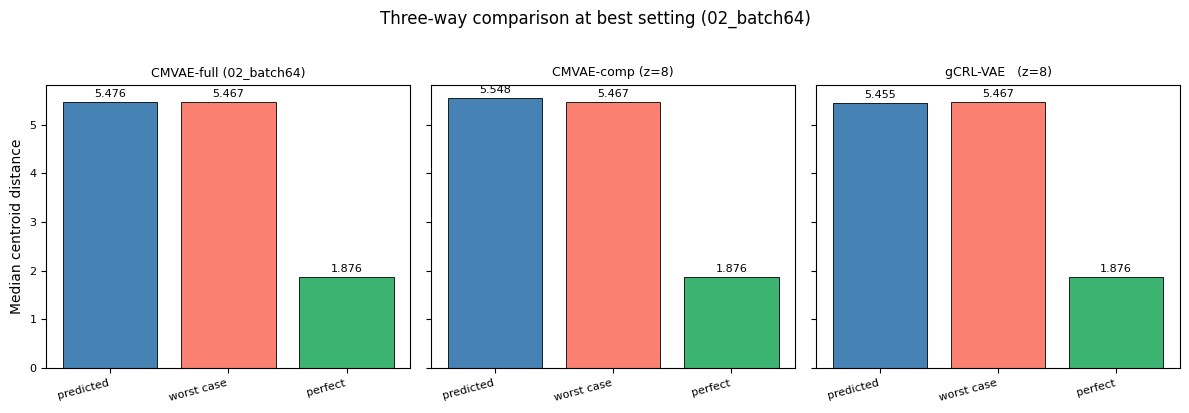

In [14]:
# Bar chart: three-way comparison
methods_order = ["actual", "worst_case", "perfect_baseline"]
method_colors = {"actual": "steelblue", "worst_case": "salmon", "perfect_baseline": "mediumseagreen"}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (label, m) in zip(axes, _three_way):
    cd = m[m["metric_name"] == "centroid_distance"]
    vals = cd.groupby("method")["metric_value"].median().reindex(methods_order)
    bars = ax.bar(
        range(len(methods_order)), vals.values,
        color=[method_colors[k] for k in methods_order],
        edgecolor="k", linewidth=0.6,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_xticks(range(len(methods_order)))
    ax.set_xticklabels(["predicted", "worst case", "perfect"], rotation=15, ha="right", fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.tick_params(labelsize=8)
    if ax is axes[0]:
        ax.set_ylabel("Median centroid distance")

plt.suptitle(f"Three-way comparison at best setting ({best_name})", y=1.02)
plt.tight_layout()
plt.show()